# 6-1 Notebook 코드를 Python 모듈로 분리하기

## 학습 목표

- Notebook에 작성한 코드를 기능별 Python 파일로 나누는 기준을 이해한다.
- 실무형 프로젝트 구조로 바꾸는 방법을 익힌다.
- 이 노트북은 리팩터링 설명과 예시 중심으로 구성한다.

## 1. 왜 모듈화가 필요한가?

Notebook은 학습과 실험에 좋지만, 실제 앱이나 서비스로 만들 때는 코드 관리가 어렵다.

모듈화의 핵심은 파일을 많이 만드는 것이 아니라, **역할을 분리하는 것**이다.

## 2. 분리 기준

| Notebook 코드 | 분리할 파일 | 역할 |
|---|---|---|
| 경로, 모델명, 설정값 | `config.py` | 전역 설정 |
| PDF 로딩 함수 | `document_loader.py` | 문서 로딩 |
| 청크 분할 함수 | `chunker.py` | 문서 분할 |
| Qdrant 생성 코드 | `vectorstore.py` | 벡터DB 관리 |
| 질문 분류, 재작성 | `retriever.py` | 검색 보조 |
| 프롬프트 | `prompts.py` | 프롬프트 관리 |
| State 정의 | `graph_state.py` | LangGraph 상태 |
| Node 함수 | `graph_nodes.py` | 그래프 노드 |
| Graph 연결 | `graph_builder.py` | 그래프 생성 |
| 실행 코드 | `main.py` | 앱 진입점 |

## 3. `config.py` 예시

In [1]:
# src/config.py

from pathlib import Path
import os
from dotenv import load_dotenv

load_dotenv(override=True, dotenv_path="../../.env")


PDF_PATH = Path('data') / "공직자_민원응대_핵심_매뉴얼.pdf"

LLM_MODEL = os.getenv("LLM_MODEL", "z-ai/glm-5.3-flash")
EMBEDDING_MODEL = os.getenv("EMBEDDING_MODEL", "nvidia/nemotron-3-embed-1b")

CHUNK_SIZE = 700
CHUNK_OVERLAP = 120
TOP_K = 4

## 4. `document_loader.py` 예시

In [3]:

# src/document_loader.py

import re
from pathlib import Path
from pypdf import PdfReader
from langchain_core.documents import Document

def clean_text(text: str) -> str:
    text = text.replace("\\x00", " ")
    text = re.sub(r"[ \\t]+", " ", text)
    text = re.sub(r"\\n{3,}", "\\n\\n", text)
    return text.strip()

def load_pdf_pages(pdf_path: Path) -> list[Document]:
    reader = PdfReader(str(pdf_path))
    docs = []

    for page_number, page in enumerate(reader.pages, start=1):
        text = clean_text(page.extract_text() or "")
        if text:
            docs.append(Document(
                page_content=text,
                metadata={"source": pdf_path.name, "page": page_number}
            ))

    return docs

## 5. `graph_builder.py` 예시

In [4]:
import sys
from pathlib import Path

def find_project_root(start: Path) -> Path:
    """
    현재 위치에서 위/아래를 탐색하여 graph_rag 폴더가 있는 프로젝트 루트를 찾는다.
    """
    start = start.resolve()

    # 1) 현재 위치와 상위 폴더들에서 graph_rag 찾기
    for path in [start, *start.parents]:
        if (path / "graph_rag").is_dir():
            return path

    # 2) 현재 위치 하위에서 graph_rag 찾기
    candidates = list(start.rglob("graph_rag"))
    candidates = [p for p in candidates if p.is_dir()]

    if candidates:
        return candidates[0].parent

    raise FileNotFoundError("graph_rag 폴더를 찾지 못했다. 현재 작업 경로를 확인해야 한다.")

BASE_DIR = find_project_root(Path.cwd())

if str(BASE_DIR) not in sys.path:
    sys.path.insert(0, str(BASE_DIR))

print("프로젝트 루트:", BASE_DIR)
print("graph_rag 존재 여부:", (BASE_DIR / "graph_rag").exists())
print("sys.path[0]:", sys.path[0])

프로젝트 루트: C:\sk-encoa\llm_workspace\6.modular_rag_manual
graph_rag 존재 여부: True
sys.path[0]: C:\sk-encoa\llm_workspace\6.modular_rag_manual


In [5]:
# graph_rag/graph_builder.py

from langgraph.graph import StateGraph, START, END
from graph_rag.graph_state import ModularRAGState
from graph_rag.graph_nodes import (
    classify_question_node,
    retrieve_manual_node,
    organize_evidence_node,
    generate_answer_node,
    validate_answer_node,
)

def build_graph():
    graph = StateGraph(ModularRAGState)

    graph.add_node("classify_question", classify_question_node)
    graph.add_node("retrieve_manual", retrieve_manual_node)
    graph.add_node("organize_evidence", organize_evidence_node)
    graph.add_node("generate_answer", generate_answer_node)
    graph.add_node("validate_answer", validate_answer_node)

    graph.add_edge(START, "classify_question")
    graph.add_edge("classify_question", "retrieve_manual")
    graph.add_edge("retrieve_manual", "organize_evidence")
    graph.add_edge("organize_evidence", "generate_answer")
    graph.add_edge("generate_answer", "validate_answer")
    graph.add_edge("validate_answer", END)

    return graph.compile()

c:\sk-encoa\llm_workspace\.venv\Lib\site-packages\langchain_nvidia_ai_endpoints\_common.py:250: UserWarning: Found nvidia/nemotron-3-embed-1b in available_models, but type is unknown and inference may fail.
  warnings.warn(


## 6. 그래프 그리기

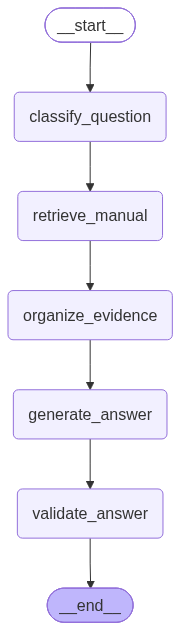

In [6]:
from graph_rag.graph_builder import build_graph
from IPython.display import Image, display

app = build_graph()
display(Image(app.get_graph().draw_mermaid_png()))

## 7. 최종 실행 흐름


In [7]:

from graph_rag.graph_builder import build_graph

app = build_graph()

result = app.invoke({
    "question": "민원인이 반복 전화를 하면 어떻게 해야 하나요?"
})

print(result["answer"])

# 민원인 반복 전화 응대 매뉴얼

## 1. 핵심 대응

- **판단 기준**: 동일민원을 **3회 이상** 제기하는 경우 '정당한 사유 없는 반복 전화'에 해당합니다.
- **기본 원칙**: 다른 민원 처리를 위해 **통화 지속 곤란을 안내한 후 종료**합니다.
- **대응 태도**: 감정적 맞대응을 하지 않고, 법령·규정에 근거한 원칙적 대응을 하며, 증거자료를 확보하고, 개인이 아닌 **부서 차원**에서 대응합니다.

## 2. 단계별 조치

### 1단계: 통화 곤란 안내 후 상담 종료
반복전화의 사유에 따라 안내 내용을 구분합니다.

| 상황 | 조치 |
|------|------|
| 정당한 행정처분에 불복하여 반복전화 | "정해진 규정과 절차에 따라 정상적으로 처리된 사항"임을 안내하고, 동일한 답변 외에는 도움을 드릴 수 없으므로 통화 종료를 양해 요청 ※ 국민권익위원회 고충민원 등 신청 안내 |
| 충분한 설명이 이루어졌음에도 반복전화 | "충분히 설명드렸고, 다른 분들의 민원처리가 지연되고 있어 통화를 종료하겠다"고 안내 ※ 지속 시 공무방해행위에 해당됨을 경고 |

### 2단계: 상황 보고
- **부서장 보고**
- 반복전화를 받은 부서원에게 **30분 이내 휴게시간 부여 가능**
- 통화 내용과 정도를 감안하여 필요시 **위법행위 관리대장을 작성하여 채증**

### 3단계: 종료 이후에도 계속 전화할 경우
- 담당자에게 휴게시간 부여 등 **응대를 중지하도록 조치**하고, **상급자 등이 응대**하여 추가 설명 후 전화 종료
- 그럼에도 반복전화가 지속되면 다른 민원처리를 위해 **해당 전화를 일시적으로 응대 보류**

## 3. 사용할 수 있는 안내 표현

- "정해진 규정과 절차에 따라 정상적으로 처리된 사항입니다. 동일한 답변 외에는 도움을 드릴 수 없어 통화 종료를 양해 부탁드립니다."
- "이의가 있으신 경우 국민권익위원회에 고충민원을 신청하실 수 있습니다."
- "충분히 설명드렸고, 다른 분들의 민원처리가 지연되고 있어 통

## 핵심 정리

- Notebook은 학습용이다.
- `src/` 구조는 앱 개발과 유지보수용이다.
- Modular RAG는 기능을 분리하고, LangGraph는 그 기능들을 흐름으로 연결한다.